# Waveform I/O examplefor the SXS catalogue.
## Authors: Vaishak Prasad

[comment]: <> (Abstract: TODO)

**Notebook Status:** <font color='green'><b> Production </b></font> 

**Notes:** 
Initiated on 5 Mar 2023

## Introduction:
This notebook describes the sub-routines for 

1. Loading SXS waveform data (Strain $rh/M$ and $\Psi_4$) into modes_array.
2. Loading into waveforms modes_array

In [1]:
import numpy as np
import waveformtools
import matplotlib.pyplot as plt

#####################
# matplotlib presets
#########################################

labelsize=16
labelpad=14

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"figure.figsize" : (8,6)})
plt.rcParams.update({"axes.grid" : True})
plt.rcParams.update({"axes.labelpad" : labelpad})
plt.rcParams.update({"axes.labelsize" : labelsize})
plt.rcParams.update({"figure.autolayout" : True})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({'legend.markerscale': 12})

In [2]:
%%bash
python --version
conda info --envs | grep '*'

Python 3.10.11
nrcat                 *  /home/vaishakprasad/soft/anaconda3/envs/nrcat


In [3]:
np.show_config()

openblas64__info:
    libraries = ['openblas64_', 'openblas64_']
    library_dirs = ['/usr/local/lib']
    language = c
    define_macros = [('HAVE_CBLAS', None), ('BLAS_SYMBOL_SUFFIX', '64_'), ('HAVE_BLAS_ILP64', None)]
    runtime_library_dirs = ['/usr/local/lib']
blas_ilp64_opt_info:
    libraries = ['openblas64_', 'openblas64_']
    library_dirs = ['/usr/local/lib']
    language = c
    define_macros = [('HAVE_CBLAS', None), ('BLAS_SYMBOL_SUFFIX', '64_'), ('HAVE_BLAS_ILP64', None)]
    runtime_library_dirs = ['/usr/local/lib']
openblas64__lapack_info:
    libraries = ['openblas64_', 'openblas64_']
    library_dirs = ['/usr/local/lib']
    language = c
    define_macros = [('HAVE_CBLAS', None), ('BLAS_SYMBOL_SUFFIX', '64_'), ('HAVE_BLAS_ILP64', None), ('HAVE_LAPACKE', None)]
    runtime_library_dirs = ['/usr/local/lib']
lapack_ilp64_opt_info:
    libraries = ['openblas64_', 'openblas64_']
    library_dirs = ['/usr/local/lib']
    language = c
    define_macros = [('HAVE_CBLAS', None

# Load SXS strain type data

In [4]:
fdir = "/home/vaishakprasad/.cache/sxs/SXS:BBH:0001v3/Lev5"
fname = 'rhOverM_Asymptotic_GeometricUnits_CoM.h5'
#get_ell_max_RIT(fdir)

In [5]:
from waveformtools.waveforms import modes_array

In [6]:
wf1 = modes_array(label='sxs_001', spin_weight=-2)

In [7]:
wf1.file_name = fname
wf1.data_dir = fdir

In [8]:
%%time
wf1.load_modes(ftype='SpEC', var_type='strain', ell_max='auto', resam_type='auto')

Passing /home/vaishakprasad/.cache/sxs/SXS:BBH:0001v3/Lev5 rhOverM_Asymptotic_GeometricUnits_CoM.h5
Chosen ell max 8 Available ell_max 8
Constructing the modes list
Creating modes data
Min dt 0.06 and Max dt 0.5
Resampling at the default timestep 0.5
auto


/home/vaishakprasad/Documents/Codes/waveformtools/waveformtools/dataIO.py:916: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  dt_auto = round(mode(np.diff(time_axis))[0][0], 4)


CPU times: user 3.28 s, sys: 1.19 s, total: 4.47 s
Wall time: 4.52 s


In [9]:
wf1.get_metadata()

{'label': 'sxs_001',
 'data_dir': '/home/vaishakprasad/.cache/sxs/SXS:BBH:0001v3/Lev5',
 'file_name': 'rhOverM_Asymptotic_GeometricUnits_CoM.h5',
 'key_format': None,
 'ell_max': 8,
 'modes_list': [[2, [-2, -1, 0, 1, 2]],
  [3, [-3, -2, -1, 0, 1, 2, 3]],
  [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]],
  [5, [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]],
  [6, [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]],
  [7, [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]],
  [8, [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]]],
 'r_ext': 500,
 'frequency_axis': None,
 'out_file_name': None,
 'maxtime': None,
 'date': '2023-04-24',
 'time': '08:44:11',
 'key_ex': None,
 'spin_weight': -2}

In [10]:
wf1.delta_t()

0.5

In [11]:
wf1.modes_list

[[2, [-2, -1, 0, 1, 2]],
 [3, [-3, -2, -1, 0, 1, 2, 3]],
 [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]],
 [5, [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]],
 [6, [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]],
 [7, [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]],
 [8, [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]]]

In [12]:
wf1.mode(2, 2)

array([-0.00024428-0.00098626j, -0.00023978-0.00099435j,
       -0.00023529-0.00100256j, ...,  0.00058476-0.00260204j,
        0.00058163-0.00260321j,  0.00057883-0.00260444j])

In [13]:
wf1.time_axis

array([-9639. , -9638.5, -9638. , ...,   380.5,   381. ,   381.5])

/home/vaishakprasad/soft/anaconda3/envs/nrcat/lib/python3.10/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


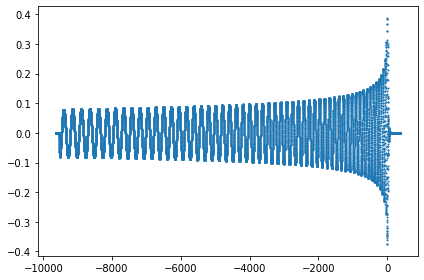

In [14]:
plt.scatter(wf1.time_axis, wf1.mode(2, 2), s=1)
plt.grid()
plt.show()


In [15]:
np.amax(np.absolute(wf1.mode(2, 2)))

0.3947193908965411

In [16]:
wf1.spin_weight = -2

In [17]:
# Simulation name

# Parameters
M = 40
D = 1000
inc = np.pi/6
coa_phase = np.pi/4
delta_t = 1./2048

In [18]:
taxis, hp, hx = wf1.to_td_waveform(Mtotal=M, distance=D, incl_angle=inc, delta_t=delta_t)

In [19]:
taxis

array([-1.89399853, -1.89351024, -1.89302196, ...,  0.07377491,
        0.07426319,  0.07475147])

In [20]:
hp

array([-2.43436604e-25, -2.21764129e-25, -1.98862064e-25, ...,
        3.12129686e-24,  3.11600452e-24,  3.09776420e-24])

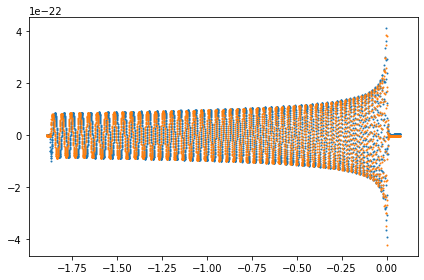

In [25]:
plt.scatter(taxis, hp, s=1)
plt.scatter(taxis, hx, s=1)
plt.grid()
plt.show()